In [1]:
%load_ext autoreload
%autoreload 2
import sys,os
sys.path.append('../')   
import numpy as np
from model.exactPreference import  exactPreference
from model.LuceJND import  LuceJND
from model.erroneousPreference import  erroneousPreference
from model.gaussianNoisePreferenceFull import  gaussianNoisePreference
from kernel.jaxrbf import RBF
from utility import  paramz
# for plotting
import matplotlib.pyplot as plt
import arviz as az
from scipy import stats

In [2]:
# 2d utility function
np.random.seed(42)
bounds=[[10,25],
        [25,64]]


# fun now takes a 2d input
def fun2d(x,noise=0):
    opt1 = np.array([15, 35])
    opt2 = np.array([20, 50])
    opt3 = np.array([23, 40])
    return (0.4*np.exp(-np.linalg.norm(x-opt1,axis=1)**2/50)+0.4*np.exp(-np.linalg.norm(x-opt2,axis=1)**2/40)+0.2*np.exp(-np.linalg.norm(x-opt3,axis=1)**2/30))+noise

/var/folders/kr/khb9b0717sndpgm3hjm3crm80000gp/T/ipykernel_48076/3543988817.py:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')


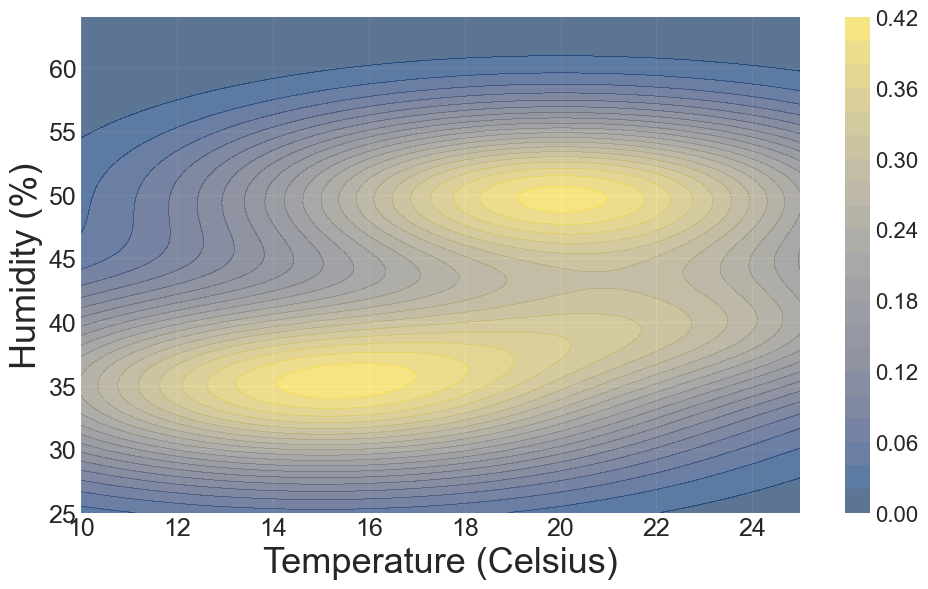

In [3]:
x1 = np.linspace(bounds[0][0], bounds[0][1], 100)
x2 = np.linspace(bounds[1][0], bounds[1][1], 100)
X1, X2 = np.meshgrid(x1, x2)
Z = fun2d(np.column_stack([X1.ravel(), X2.ravel()]))
Z = Z.reshape(X1.shape)
plt.style.use('seaborn-darkgrid')
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, Z, levels=20, cmap='cividis',alpha=0.6)
cbar=plt.colorbar()#label='Function Value')
cbar.ax.tick_params(labelsize=16) 
plt.xlabel('Temperature (Celsius)',size=26)
plt.ylabel('Humidity (%)',size=26)
plt.xticks(size=18)
plt.yticks(size=18)
#plt.title('')
plt.tight_layout()
plt.show()

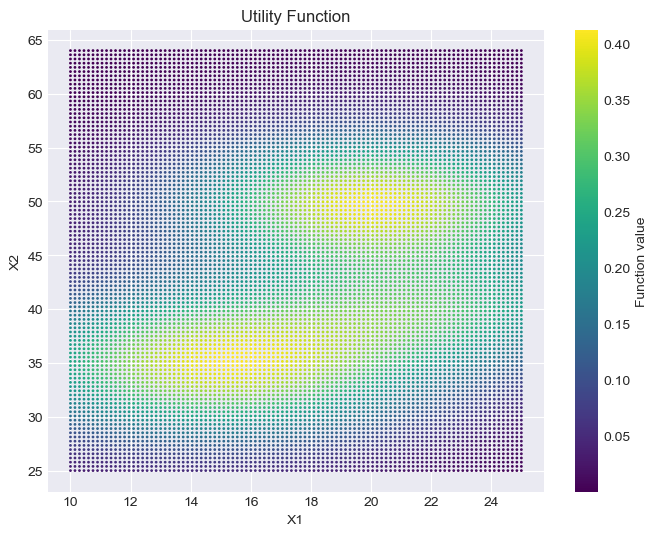

In [4]:
# create a two-dimensional grid, evaluate the function fun2d and plot
Xpred = np.array([[x,y] for x in np.linspace(bounds[0][0],bounds[0][1],101) for y in np.linspace(bounds[1][0],bounds[1][1],101)])
Ypred = fun2d(Xpred)
# plot the function
plt.figure(figsize=(8,6))
plt.scatter(Xpred[:,0],Xpred[:,1],c=Ypred,cmap='viridis',s=1)
plt.colorbar(label='Function value')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Utility Function')
plt.show()

## Initialize functions

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

In [6]:
def compute_transitive_instances(Pairs):
    transitive_instances = []
    for i in range(len(Pairs)):
        for j in range(len(Pairs)):
            if j == i:
                continue
            if (Pairs[i][1] == Pairs[j][0]):
                restricted_pairs_right = Pairs[(Pairs[:]==Pairs[j][1])[:,1]]
                ind_restricted_pairs_right = np.where((Pairs[:]==Pairs[j][1])[:,1])[0]
                if (np.isin(Pairs[i][0], restricted_pairs_right[:,0]).any()):
                    k = np.where(restricted_pairs_right[:,0]==Pairs[i][0])[0][0]
                    transitive_instances.append((i, j,ind_restricted_pairs_right[k]))
    return transitive_instances

In [7]:
def train_Preferences(data, prefClass, kernel=RBF,params=None,nsamples=60000,niterations=200,inf_method='Laplace'):

    #kernel parameter dictionary
    if params is None:
       params={'lengthscale': {'value':1.0*np.ones(data["X"].shape[1],float), 
                            'range':np.vstack([[0.1, 3.0]]*data["X"].shape[1]),
                            'transform': paramz.logexp()},
               'variance': {'value':np.array([1.0]), 
                            'range':np.vstack([[0.01, 100.0]]),
                            'transform': paramz.logexp()}, #variance not used in exactPreference
                'noise_variance': {'value':np.array([0.5]), 
                        'range':np.vstack([[0.001, 10.001]]),
                        'transform': paramz.logexp()} #variance not used in exactPreference
              }
    else:
        params = params

    # define preference model 
    model = prefClass(data,kernel,params,inf_method=inf_method)
    # compute hyperparameters
    model.optimize_hyperparams(niterations=niterations)
    print(model.params)
    # sample from posterior
    model.sample(nsamples=nsamples, tune=5000)
    

    return model

In [8]:
def define_train_test_indices_with_transitivity(Pairs, proportion_test=0.33, rnd_state=42):

    train_indices, test_indices = train_test_split(np.arange(len(Pairs)), test_size=proportion_test, random_state=rnd_state)

    print("*** First step: create random train/test split ***")
    print("Number of pairs in total:", len(Pairs))
    print("Number of pairs in train set:", train_indices.shape[0])
    print("Number of pairs in test set:", test_indices.shape[0])
    # print("train_indices:", train_indices)
    # print("test_indices:", test_indices)
    
    # compute transitive instances
    print("*** Second step: compute transitive instances ***")
    transitive_instances = compute_transitive_instances(Pairs)
    # print(transitive_instances)
    print("Number of transitive instances:", len(transitive_instances))
    print("with", np.unique(transitive_instances).shape[0], "unique indices in total.")

    print("*** Third step: adjust train/test indices to have first two pairs of triple in train and last one in test ***")
    # Select the first two indices and the last index of the transitive instances
    # The first two indices will go into the training set, the last index will go into the test set
    first_two_indices = []
    last_index = []
    for i, j, k in transitive_instances:
        first_two_indices.append((i, j))
        last_index.append(k)
    last_index_np = np.unique(np.array(last_index))
    first_two_indices_np = np.unique(np.array(first_two_indices).flatten())
    # If there is a pair both in first_two_indices and last_index, remove it from last_index
    last_index_np=last_index_np[~np.isin(last_index_np, first_two_indices_np)]
    
    # save the indices that need to go from train to test and from test to train
    idx_from_train_to_test = train_indices[np.isin(train_indices, last_index_np)]
    print("There are ", idx_from_train_to_test.shape[0], "indices that need to go from train to test.")
    idx_from_test_to_train = test_indices[np.isin(test_indices, first_two_indices_np)]
    print("There are ", idx_from_test_to_train.shape[0], "indices that need to go from test to train.")
    # print(idx_from_test_to_train)

    # remove the indices from train_indices that are in idx_from_train_to_test and add them to test_indices
    train_indices=np.setdiff1d(train_indices, idx_from_train_to_test)
    test_indices=np.concatenate((test_indices, idx_from_train_to_test))
    # print("train_indices:", train_indices)
    # print("test_indices:", test_indices)

    # remove the indices from test_indices that are in idx_from_test_to_train and add them to train_indices
    test_indices=np.setdiff1d(test_indices, idx_from_test_to_train)
    train_indices=np.concatenate((train_indices, idx_from_test_to_train))
    # print("train_indices:", train_indices)
    # print("test_indices:", test_indices)

    # Check that we did not lose any indices. 
    print(np.sum(np.isin(np.sort(train_indices), np.sort(first_two_indices_np))), np.sum(np.isin(np.sort(test_indices), np.sort(first_two_indices_np))))
    assert np.sum(np.isin(np.sort(test_indices), np.sort(first_two_indices_np))) == 0

    print(np.sum(np.isin(np.sort(train_indices), np.sort(last_index_np))), np.sum(np.isin(np.sort(test_indices), np.sort(last_index_np))))
    assert np.sum(np.isin(np.sort(train_indices), np.sort(last_index_np))) == 0

    return train_indices, test_indices, last_index_np

In [9]:
def generatePairs(X,m,seed_test=42):

    np.random.seed(seed_test)
    Pairs=[]
    for ii in range(m):
        i=np.random.randint(X.shape[0])
        j=np.random.randint(X.shape[0])
        if i != j:
            if fun2d(X[i].reshape(1,-1),noise[i])>fun2d(X[j].reshape(1,-1),noise[j]):
                Pairs.append([i,j])# i is preferred to j
            elif fun2d(X[j].reshape(1,-1),noise[j])>fun2d(X[i].reshape(1,-1),noise[i]):
                Pairs.append([j,i])# j is preferred to i
    Pairs, indices = np.unique(Pairs, axis=0, return_index=True)
    return Pairs, indices

In [10]:
def evaluate_pair_predictions(Pairs, predictions,var):
    """
    Evaluate the pairwise predictions based on the utility function predictions.
    """
    results = []
    for i in Pairs:
        results.append(np.mean(stats.norm.cdf((predictions[i[0],:]-predictions[i[1],:])/np.sqrt(var))))
    return np.array(results)

### Loop no noise

In [11]:
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [12]:
n=20
X = np.array([[x,y] for x in np.linspace(bounds[0][0],bounds[0][1],n) for y in np.linspace(bounds[1][0],bounds[1][1],n)])
sigma=0.0
noise = sigma*np.random.randn(n*n)

In [13]:
X

array([[10.        , 25.        ],
       [10.        , 27.05263158],
       [10.        , 29.10526316],
       [10.        , 31.15789474],
       [10.        , 33.21052632],
       [10.        , 35.26315789],
       [10.        , 37.31578947],
       [10.        , 39.36842105],
       [10.        , 41.42105263],
       [10.        , 43.47368421],
       [10.        , 45.52631579],
       [10.        , 47.57894737],
       [10.        , 49.63157895],
       [10.        , 51.68421053],
       [10.        , 53.73684211],
       [10.        , 55.78947368],
       [10.        , 57.84210526],
       [10.        , 59.89473684],
       [10.        , 61.94736842],
       [10.        , 64.        ],
       [10.78947368, 25.        ],
       [10.78947368, 27.05263158],
       [10.78947368, 29.10526316],
       [10.78947368, 31.15789474],
       [10.78947368, 33.21052632],
       [10.78947368, 35.26315789],
       [10.78947368, 37.31578947],
       [10.78947368, 39.36842105],
       [10.78947368,

In [14]:
X.shape

(400, 2)

In [15]:
all_results = []

In [16]:
#for seed_test in range(50):
seed_test = 42

print("##########################")
print(f"Running seed {seed_test}...")
print("##########################")
# Generate pairs
Pairs, indices = generatePairs(X, 600, seed_test=seed_test)
print("Number of pairs generated:", len(Pairs))
print("Example of a Pair:")
print(Pairs[0], X[Pairs[0][0]], X[Pairs[0][1]], fun2d(X[Pairs[0][0]].reshape(1,-1), noise[Pairs[0][0]]), fun2d(X[Pairs[0][1]].reshape(1,-1), noise[Pairs[0][1]]))

# Adjust transitivity
train_indices, test_indices, last_index_np = define_train_test_indices_with_transitivity(Pairs, proportion_test=0.33, rnd_state=seed_test)

# Train /test split
Pairs_train = Pairs[train_indices]
Pairs_test = Pairs[test_indices]

params_custom={'lengthscale': {'value':1.0*np.ones(X.shape[1],float), 
                        'range':np.vstack([[0.1, 15.0]]*X.shape[1]),
                        'transform': paramz.logexp()},
            'variance': {'value':np.array([1.0]), 
                        'range':np.vstack([[0.01, 100.0]]),
                        'transform': paramz.logexp()}, #variance not used in exactPreference
            'noise_variance': {'value':np.array([0.5]), 
                        'range':np.vstack([[0.001, 10.001]]),
                        'transform': paramz.logexp()} #variance not used in exactPreference
            }

# Data dictionary train
data = {}
data["Pairs"]  = Pairs_train
data["X"] = X

#gaussianNoisePreference,erroneousPreference

mod_errPref = train_Preferences(data, prefClass=erroneousPreference, 
                                kernel=RBF, params=params_custom,
                                nsamples=10000,inf_method='advi',niterations=500)
pred_test_gp = mod_errPref.predict(X)

var=mod_errPref.params['variance']['value'][0]
ressss=evaluate_pair_predictions(Pairs_test, pred_test_gp,var=var)

accuracy_skewGP = np.mean(ressss>0.5)
print(f"Accuracy of SkewGP: {accuracy_skewGP:.2f}")
cm_skew = confusion_matrix(np.ones_like(Pairs_test[:,0]), ressss>=0.5)
print("Confusion matrix SkewGP:",cm_skew)
brier_GPerrPref = brier_score_loss(np.ones_like(Pairs_test[:,0]), ressss)
print("Brier score SkewGP:", brier_GPerrPref)

transitive_pred = evaluate_pair_predictions(Pairs[last_index_np], pred_test_gp,var=var) 

correct_trans_pred_GP = np.sum(transitive_pred>0.5)
test_indices_in_last_index = np.isin(test_indices, last_index_np)
total_transitive_tests = np.sum(test_indices_in_last_index)
print("Correctly predicted transitive instances:",correct_trans_pred_GP,
      "Out of:", total_transitive_tests)

# Save results
results = {
      "seed_test": seed_test,
      "Pairs_train": Pairs_train,
      "Pairs_test": Pairs_test,
      "train_indices": train_indices,
      "test_indices": test_indices,
      "last_index_np": last_index_np,
      "total_transitive_tests": total_transitive_tests,
      "pred_test_gp": pred_test_gp,
      "ressss": ressss,
      "accuracy_skewGP": accuracy_skewGP,
      "brier_GPerrPref": brier_GPerrPref,
      "cm_skew": cm_skew,
      "transitive_GP": correct_trans_pred_GP
}
all_results.append(results)


##########################
Running seed 42...
##########################
Number of pairs generated: 599
Example of a Pair:
[  0 238] [10. 25.] [18.68421053 61.94736842] [0.0328344] [0.01080173]
*** First step: create random train/test split ***
Number of pairs in total: 599
Number of pairs in train set: 401
Number of pairs in test set: 198
*** Second step: compute transitive instances ***
Number of transitive instances: 2
with 6 unique indices in total.
*** Third step: adjust train/test indices to have first two pairs of triple in train and last one in test ***
There are  1 indices that need to go from train to test.
There are  3 indices that need to go from test to train.
4 0
0 2
122.28095188845774
123.16902212499663
122.28095202594844
122.28095177085902
138.00533781827008


 lower bound 155.15184472504382: 100%|██████████| 500/500 [00:49<00:00, 10.19it/s]


{'lengthscale': {'value': array([0.95866881, 2.02526006]), 'range': array([[ 0.1, 15. ],
       [ 0.1, 15. ]]), 'transform': <utility.paramz.logexp object at 0x16d447d10>}, 'variance': {'value': array([2.38780121]), 'range': array([[1.e-02, 1.e+02]]), 'transform': <utility.paramz.logexp object at 0x16c967010>}, 'noise_variance': {'value': array([0.5]), 'range': array([[1.0000e-03, 1.0001e+01]]), 'transform': <utility.paramz.logexp object at 0x16ce34790>}}


100%|██████████| 15000/15000 [01:21<00:00, 185.17it/s]


Accuracy of SkewGP: 0.70
Confusion matrix SkewGP: [[  0   0]
 [ 59 137]]
Brier score SkewGP: 0.19730249416996068
Correctly predicted transitive instances: 2 Out of: 2


In [17]:
Xpred

array([[10.  , 25.  ],
       [10.  , 25.39],
       [10.  , 25.78],
       ...,
       [25.  , 63.22],
       [25.  , 63.61],
       [25.  , 64.  ]])

In [20]:
# extract from all_results the values of transitive_GP, transitive_NN, total_transitive_tests 
transitive_GP = np.array([res["transitive_GP"] for res in all_results])
total_transitive_tests = np.array([res["total_transitive_tests"] for res in all_results])

Transitive GP: [1.]


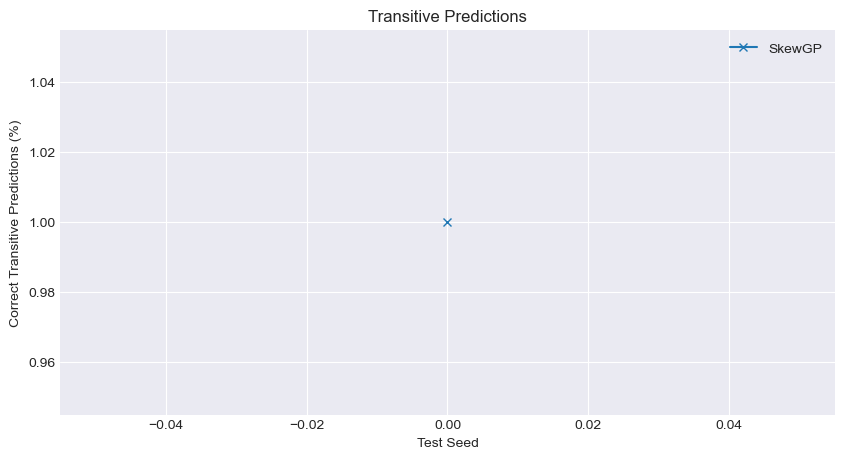

In [22]:
transitive_GP_perc = transitive_GP / total_transitive_tests
print("Transitive GP:", transitive_GP_perc)
# Plot the results
plt.figure(figsize=(10, 5))
plt.title('Transitive Predictions')
plt.plot(transitive_GP_perc, label='SkewGP', marker='x')
plt.xlabel('Test Seed')
plt.ylabel('Correct Transitive Predictions (%)')
plt.legend()


Accuracy SkewGP: [0.69897959]


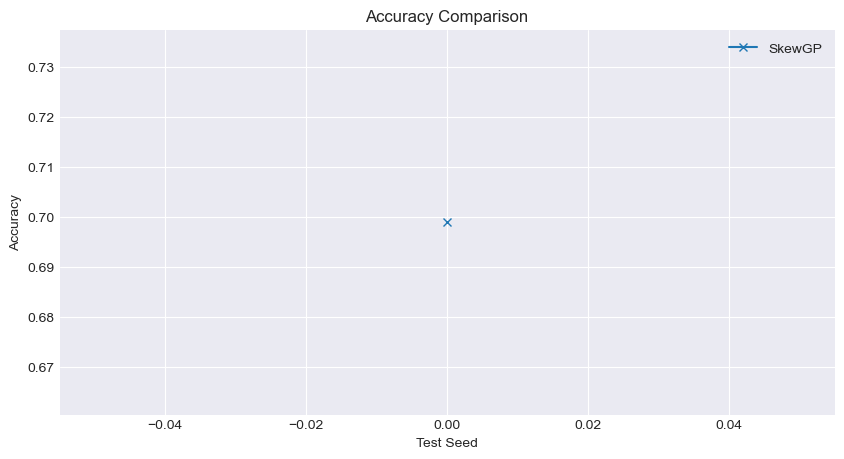

In [23]:
# extract from all_results the values of accuracy_symm and accuracy_skewGP
accuracy_skewGP = np.array([res["accuracy_skewGP"] for res in all_results])
print("Accuracy SkewGP:", accuracy_skewGP)
# Plot the results
plt.figure(figsize=(10, 5))
plt.title('Accuracy Comparison')
plt.plot(accuracy_skewGP, label='SkewGP', marker='x')
plt.xlabel('Test Seed')
plt.ylabel('Accuracy')
plt.legend()
